# Lab 6 — Frequency Domain Filtering

---
## Assessment Task — Sobel Filter in the Frequency Domain

Sobel filters detect edges — one kernel for horizontal edges (`sobel_x`), one for vertical edges (`sobel_y`). In the spatial domain these are 3×3 kernels:

$$\text{Sobel}_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} \quad \text{Sobel}_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

### Why this task is trickier than Task 1
For the Laplacian, we had a clean closed-form formula `−4π²(u² + v²)` that worked directly on the frequency grid. For Sobel, we only have 3×3 kernels. To use them in the frequency domain, we must:

1. **Pad** each 3×3 kernel to the image's size (e.g., 256×256) by placing it in the **center** of a zero-filled array.
2. Apply `ifftshift` to move the kernel's center from the image center to pixel (0, 0) — the convention FFT expects.
3. FFT the padded kernel to get its frequency response.
4. Multiply with the image's FFT.
5. Inverse FFT to get the result.

The helper function `center_embed_kernel` (provided in the lab) does steps 1–3 for us.

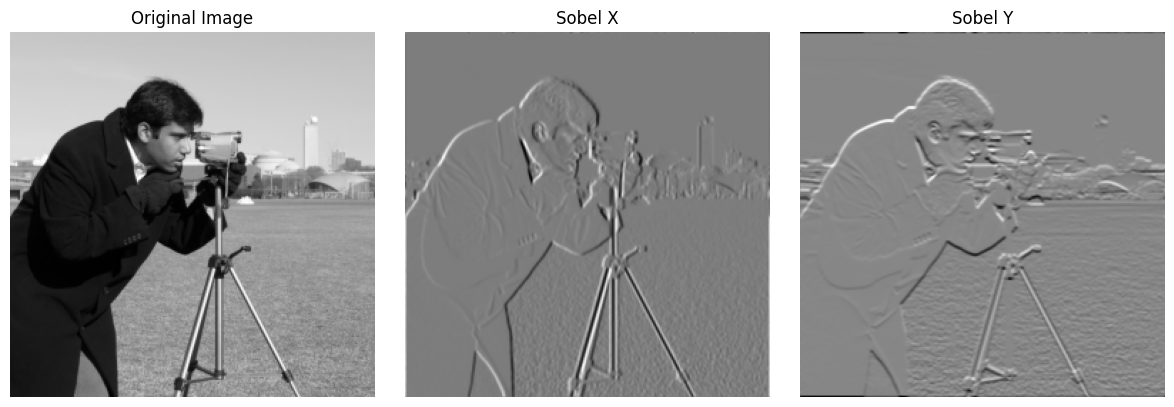

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, fftshift, ifftshift

%matplotlib inline

image=data.camera()
image=resize(image, (256, 256))

sobel_x=np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]])

sobel_y=np.array([
    [-1,-2,-1],
    [ 0,0,0],
    [ 1,2,1]])

def center_embed_kernel(kernel,shape):
    M,N=shape
    kh,kw=kernel.shape
    H=np.zeros((M,N))
    r=M//2-kh//2
    c=N//2-kw//2
    H[r:r+kh,c:c+kw]=kernel
    H=ifftshift(H)
    return fft2(H)

F=fft2(image)

H_x=center_embed_kernel(sobel_x,image.shape)
H_y=center_embed_kernel(sobel_y,image.shape)
G_x=F*H_x
G_y=F*H_y

sobel_x_image=np.real(ifft2(G_x))
sobel_y_image=np.real(ifft2(G_y))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image,cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sobel_x_image,cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sobel_y_image,cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.tight_layout()
plt.show()